# Feature-by-feature comparison: Ground Truth vs Model Prediction
Универсальный ноутбук. Настройте `CONFIG` ниже и запускайте.

In [11]:

# ═══════════════════════════════════════════════════════════════════════════
#  КОНФИГ — меняйте только здесь
# ═══════════════════════════════════════════════════════════════════════════

EXPERIMENT_ID = 25475          # ID чекпоинта в папке experiments/

# Путь к файлу данных относительно корня проекта (где run_models.py).
DATA_PATH = 'data/HopperPhysics/training.pt'

# Индексы траекторий для визуализации
TRAJ_INDICES = [0, 1, 2, 3, 4]

# Доля наблюдаемых точек (начало), остальное — предсказываем
# Должно совпадать с тем, что в lib/utils.py (сейчас 1/2)
OBS_FRACTION = 1 / 3

# Имена каналов (None = авто: 'dim 0', 'dim 1', ...)
CHANNEL_NAMES = [
    'rootz (высота)',
    'rooty (угол туловища)',
    'thigh (угол бедра)',
    'leg (угол голени)',
    'foot (угол ступни)',
    'vx (гориз. скорость)',
    'vz (верт. скорость)',
    'vrooty', 'vthigh', 'vleg', 'vfoot',
    'touch_foot', 'touch_toe', 'extra',
]
# ═══════════════════════════════════════════════════════════════════════════


In [12]:
import os, sys
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from pathlib import Path

def find_project_root(marker='run_models.py'):
    """Ищет корень проекта вверх по дереву от CWD."""
    current = Path.cwd().resolve()
    for _ in range(8):
        if (current / marker).exists():
            return current
        current = current.parent
    raise RuntimeError(f'Не найден корень проекта (нет {marker})')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

%matplotlib inline

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.distributions import Normal

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('ROOT:', ROOT)
print('device:', DEVICE)


ROOT: D:\Skoltech\ML\Project\code\asa-ode
device: cuda


In [13]:
# ── загрузка и нормализация данных ────────────────────────────────────────
def load_dataset(path):
    p = Path(path)
    if p.suffix == '.npy':
        arr = np.load(p)
    elif p.suffix == '.npz':
        d = np.load(p)
        arr = d[list(d.keys())[0]]
    else:
        obj = torch.load(p, map_location='cpu', weights_only=False)
        if isinstance(obj, torch.Tensor):
            arr = obj.numpy()
        elif isinstance(obj, np.ndarray):
            arr = obj
        elif isinstance(obj, dict):
            for key in ('data', 'trajectories', 'samples', list(obj.keys())[0]):
                if key in obj:
                    v = obj[key]
                    arr = v.numpy() if isinstance(v, torch.Tensor) else np.array(v)
                    break
        else:
            raise ValueError(f'Неизвестный формат: {type(obj)}')
    if arr.ndim == 2:
        arr = arr[np.newaxis]
    return arr.astype(np.float32)


data_raw = load_dataset(DATA_PATH)
N, T, C = data_raw.shape
print(f'Данные (raw): {N} траекторий, T={T}, C={C}')

# Нормализация как в mujoco_physics.py:
#   data_norm = (data - att_min) / att_max
reshaped = data_raw.reshape(-1, C)
att_min  = reshaped.min(axis=0)   # (C,)
att_max  = reshaped.max(axis=0)   # (C,)
att_max[att_max == 0.] = 1.

data_norm = (data_raw - att_min) / att_max   # используется для инференса и MSE

print(f'att_min: {att_min.round(3)}')
print(f'att_max: {att_max.round(3)}')

# автоимена каналов
if CHANNEL_NAMES is None or len(CHANNEL_NAMES) < C:
    CHANNEL_NAMES = [f'dim {i}' for i in range(C)]


Данные (raw): 10000 траекторий, T=200, C=14
att_min: [  -6.154   -0.983  -11.755   -2.      -2.926   -1.999   -2.      -8.783
   -9.323  -47.243  -43.079  -59.637  -54.284 -118.463]
att_max: [ 6.702  2.773 12.485  2.     1.998  2.909  2.     9.737  7.613 66.82
 93.305 30.623 72.312 86.629]


In [14]:
# ── загрузка модели ────────────────────────────────────────────────────────
from lib.create_latent_ode_model import create_LatentODE_model

ckpt_path = ROOT / 'experiments' / f'experiment_{EXPERIMENT_ID}.ckpt'
ckpt      = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
ckpt_args = ckpt['args']

obsrv_std = torch.Tensor([1e-3]).to(DEVICE)
z0_prior  = Normal(torch.zeros(1).to(DEVICE), torch.ones(1).to(DEVICE))
model     = create_LatentODE_model(ckpt_args, C, z0_prior, obsrv_std, DEVICE)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print(f'Модель загружена: experiment_{EXPERIMENT_ID}')
print(f'encoder: {ckpt_args.z0_encoder}')

Модель загружена: experiment_25475
encoder: odernn


In [15]:
# ── инференс (на нормализованных данных) ──────────────────────────────────
def predict(traj_norm_np, obs_fraction=OBS_FRACTION):
    """
    traj_norm_np: нормализованная траектория (T, C).
    Возвращает pred_norm (T_pred, C) и split_t.
    """
    T_total = len(traj_norm_np)
    split_t = max(1, int(T_total * obs_fraction))

    time_steps = torch.linspace(0.0, 1.0, T_total, device=DEVICE)
    obs  = torch.tensor(traj_norm_np[:split_t], dtype=torch.float32, device=DEVICE).unsqueeze(0)
    mask = torch.ones(1, split_t, traj_norm_np.shape[-1], device=DEVICE)

    with torch.no_grad():
        pred, _ = model.get_reconstruction(
            time_steps_to_predict = time_steps[split_t:],
            truth                 = obs,
            truth_time_steps      = time_steps[:split_t],
            mask                  = mask,
            n_traj_samples        = 1,
            mode                  = 'extrap',
        )
    return pred[0, 0].cpu().numpy(), split_t   # (T_pred, C), нормализованные


def denorm(arr):
    """Денормализация: обратная к (x - att_min) / att_max."""
    return arr * att_max + att_min


results = []
for idx in TRAJ_INDICES:
    pred_norm, split_t = predict(data_norm[idx])
    results.append(dict(
        idx     = idx,
        gt_norm = data_norm[idx],          # (T, C)  нормализованные
        gt_raw  = data_raw[idx],           # (T, C)  оригинальные
        pred_norm = pred_norm,             # (T_pred, C) нормализованные
        pred_raw  = denorm(pred_norm),     # (T_pred, C) оригинальные
        split_t = split_t,
    ))
    print(f'traj #{idx:4d}  split_t={split_t}  pred {pred_norm.shape}')


traj #   0  split_t=66  pred (134, 14)
traj #   1  split_t=66  pred (134, 14)
traj #   2  split_t=66  pred (134, 14)
traj #   3  split_t=66  pred (134, 14)
traj #   4  split_t=66  pred (134, 14)


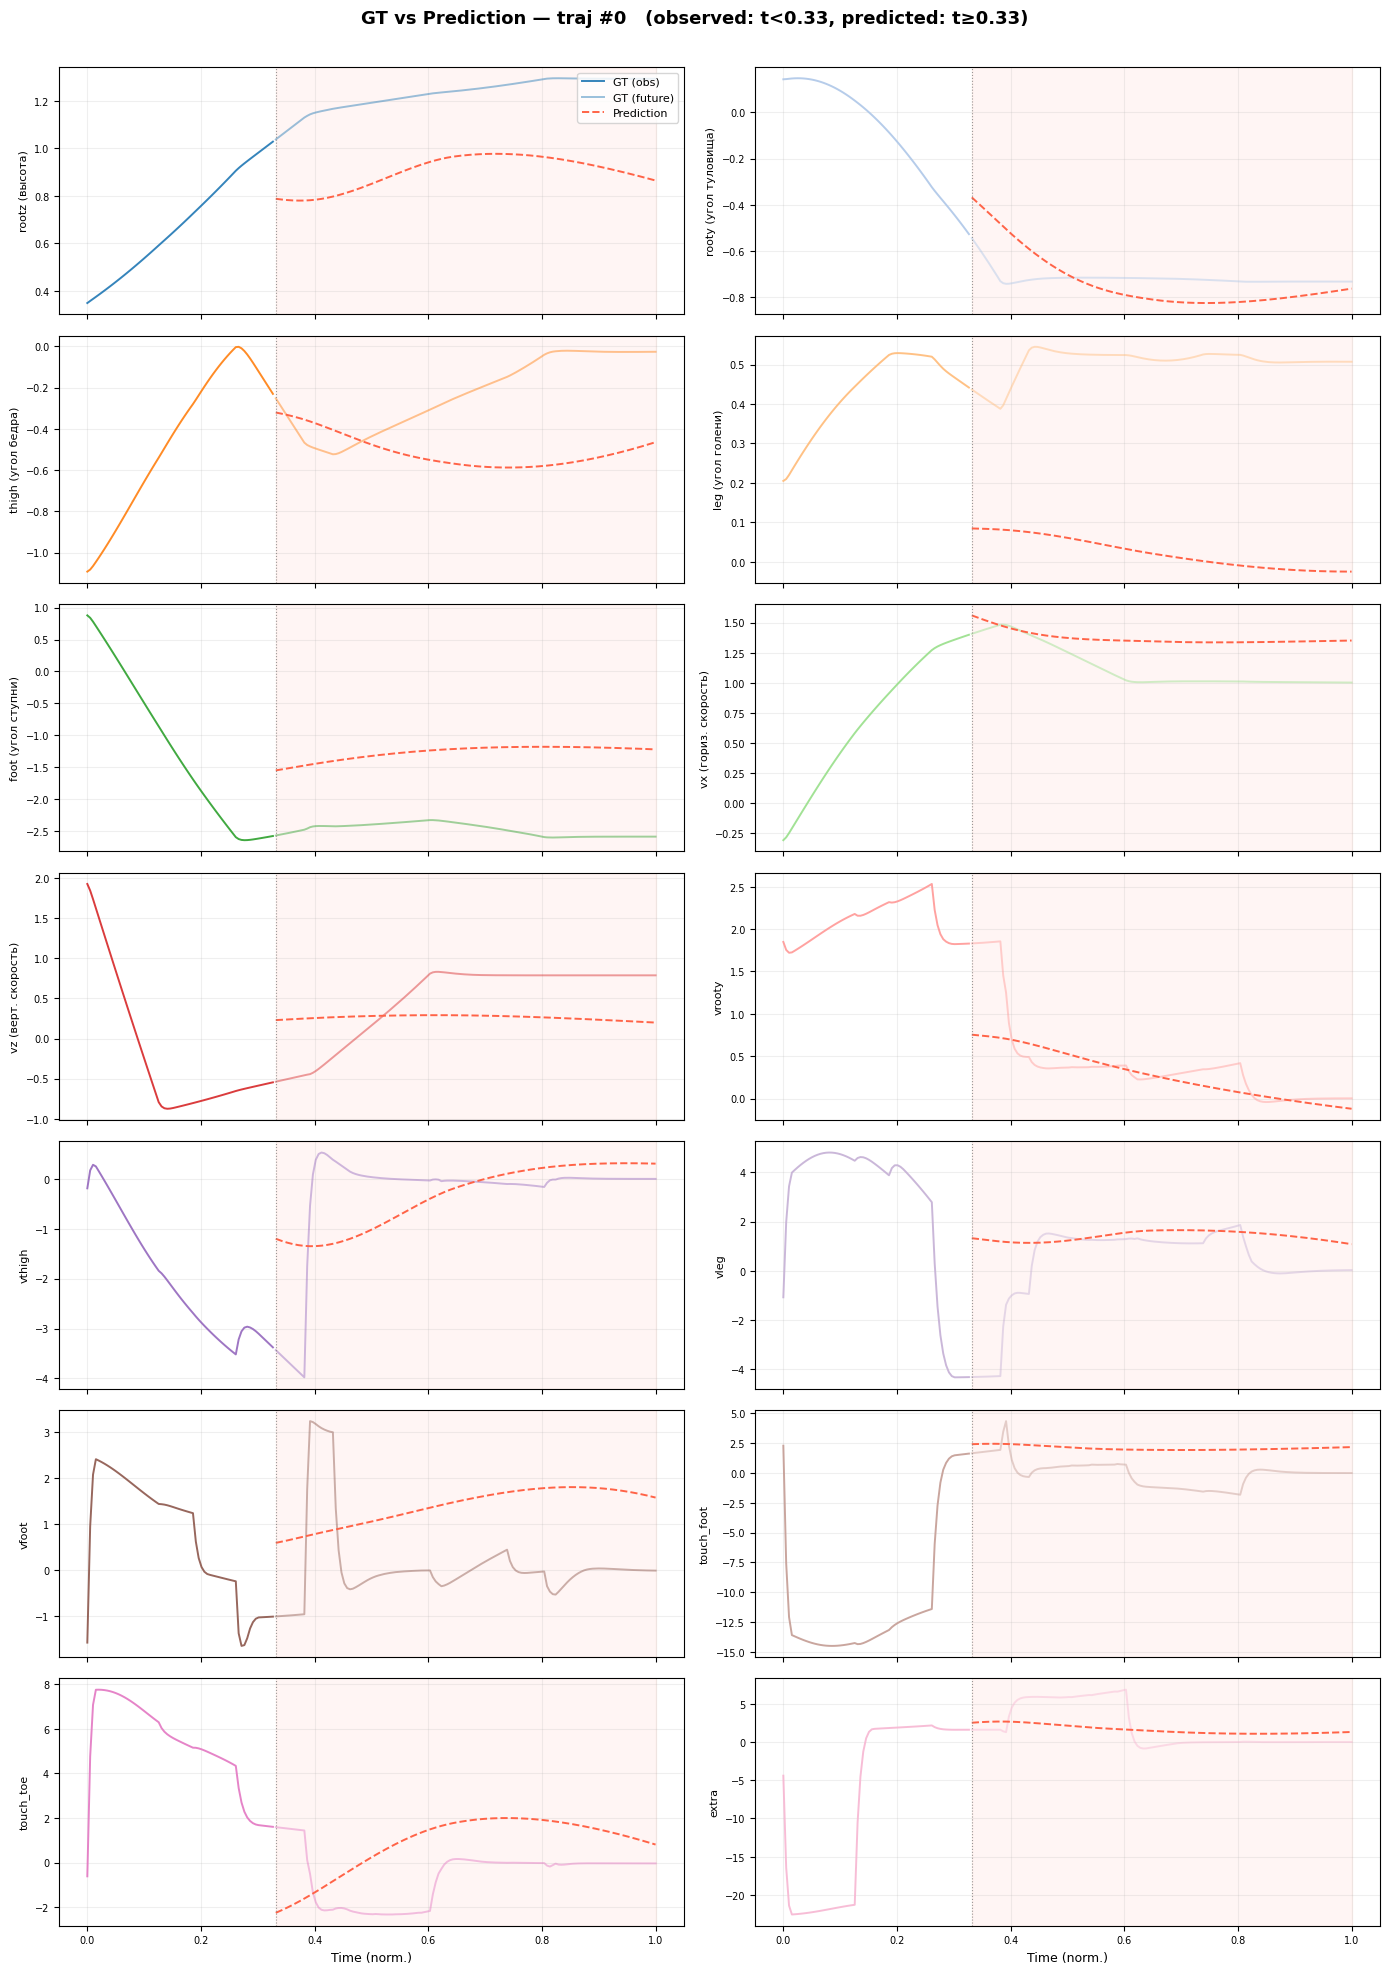

Сохранено: features_comparison_traj0.png


In [16]:
# ── все фичи для одной траектории (оригинальный масштаб) ──────────────────
WHICH = 0    # индекс в TRAJ_INDICES

r      = results[WHICH]
gt     = r['gt_raw']
pred   = r['pred_raw']
spl    = r['split_t']
t_all  = np.linspace(0, 1, T)
t_obs  = t_all[:spl]
t_pred = t_all[spl:]

cols   = 2
rows   = int(np.ceil(C / cols))
COLORS = plt.cm.tab20.colors

fig, axes = plt.subplots(rows, cols,
                          figsize=(7 * cols, 2.8 * rows),
                          sharex=True)
fig.suptitle(
    f'GT vs Prediction — traj #{r["idx"]}   '
    f'(observed: t<{spl/T:.2f}, predicted: t≥{spl/T:.2f})',
    fontsize=13, fontweight='bold', y=1.005
)
axes_flat = np.array(axes).flatten()

for ch in range(C):
    ax  = axes_flat[ch]
    clr = COLORS[ch % len(COLORS)]

    ax.plot(t_obs,  gt[:spl, ch],  color=clr,     lw=1.4, alpha=0.9,  label='GT (obs)')
    ax.plot(t_pred, gt[spl:, ch],  color=clr,     lw=1.4, alpha=0.45, label='GT (future)')
    ax.plot(t_pred, pred[:, ch],   color='tomato', lw=1.4, ls='--',   label='Prediction')

    ax.axvline(t_pred[0], color='gray', lw=0.8, ls=':', alpha=0.8)
    ax.axvspan(t_pred[0], 1.0, alpha=0.06, color='tomato')
    ax.set_ylabel(CHANNEL_NAMES[ch], fontsize=8)
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=7)
    if ch == 0:
        ax.legend(fontsize=8, loc='upper right')

for ax in axes_flat[C:]:
    ax.set_visible(False)
for ax in axes_flat[C - cols: C]:
    ax.set_xlabel('Time (norm.)', fontsize=9)

plt.tight_layout()
fname = f'features_comparison_traj{r["idx"]}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено:', fname)


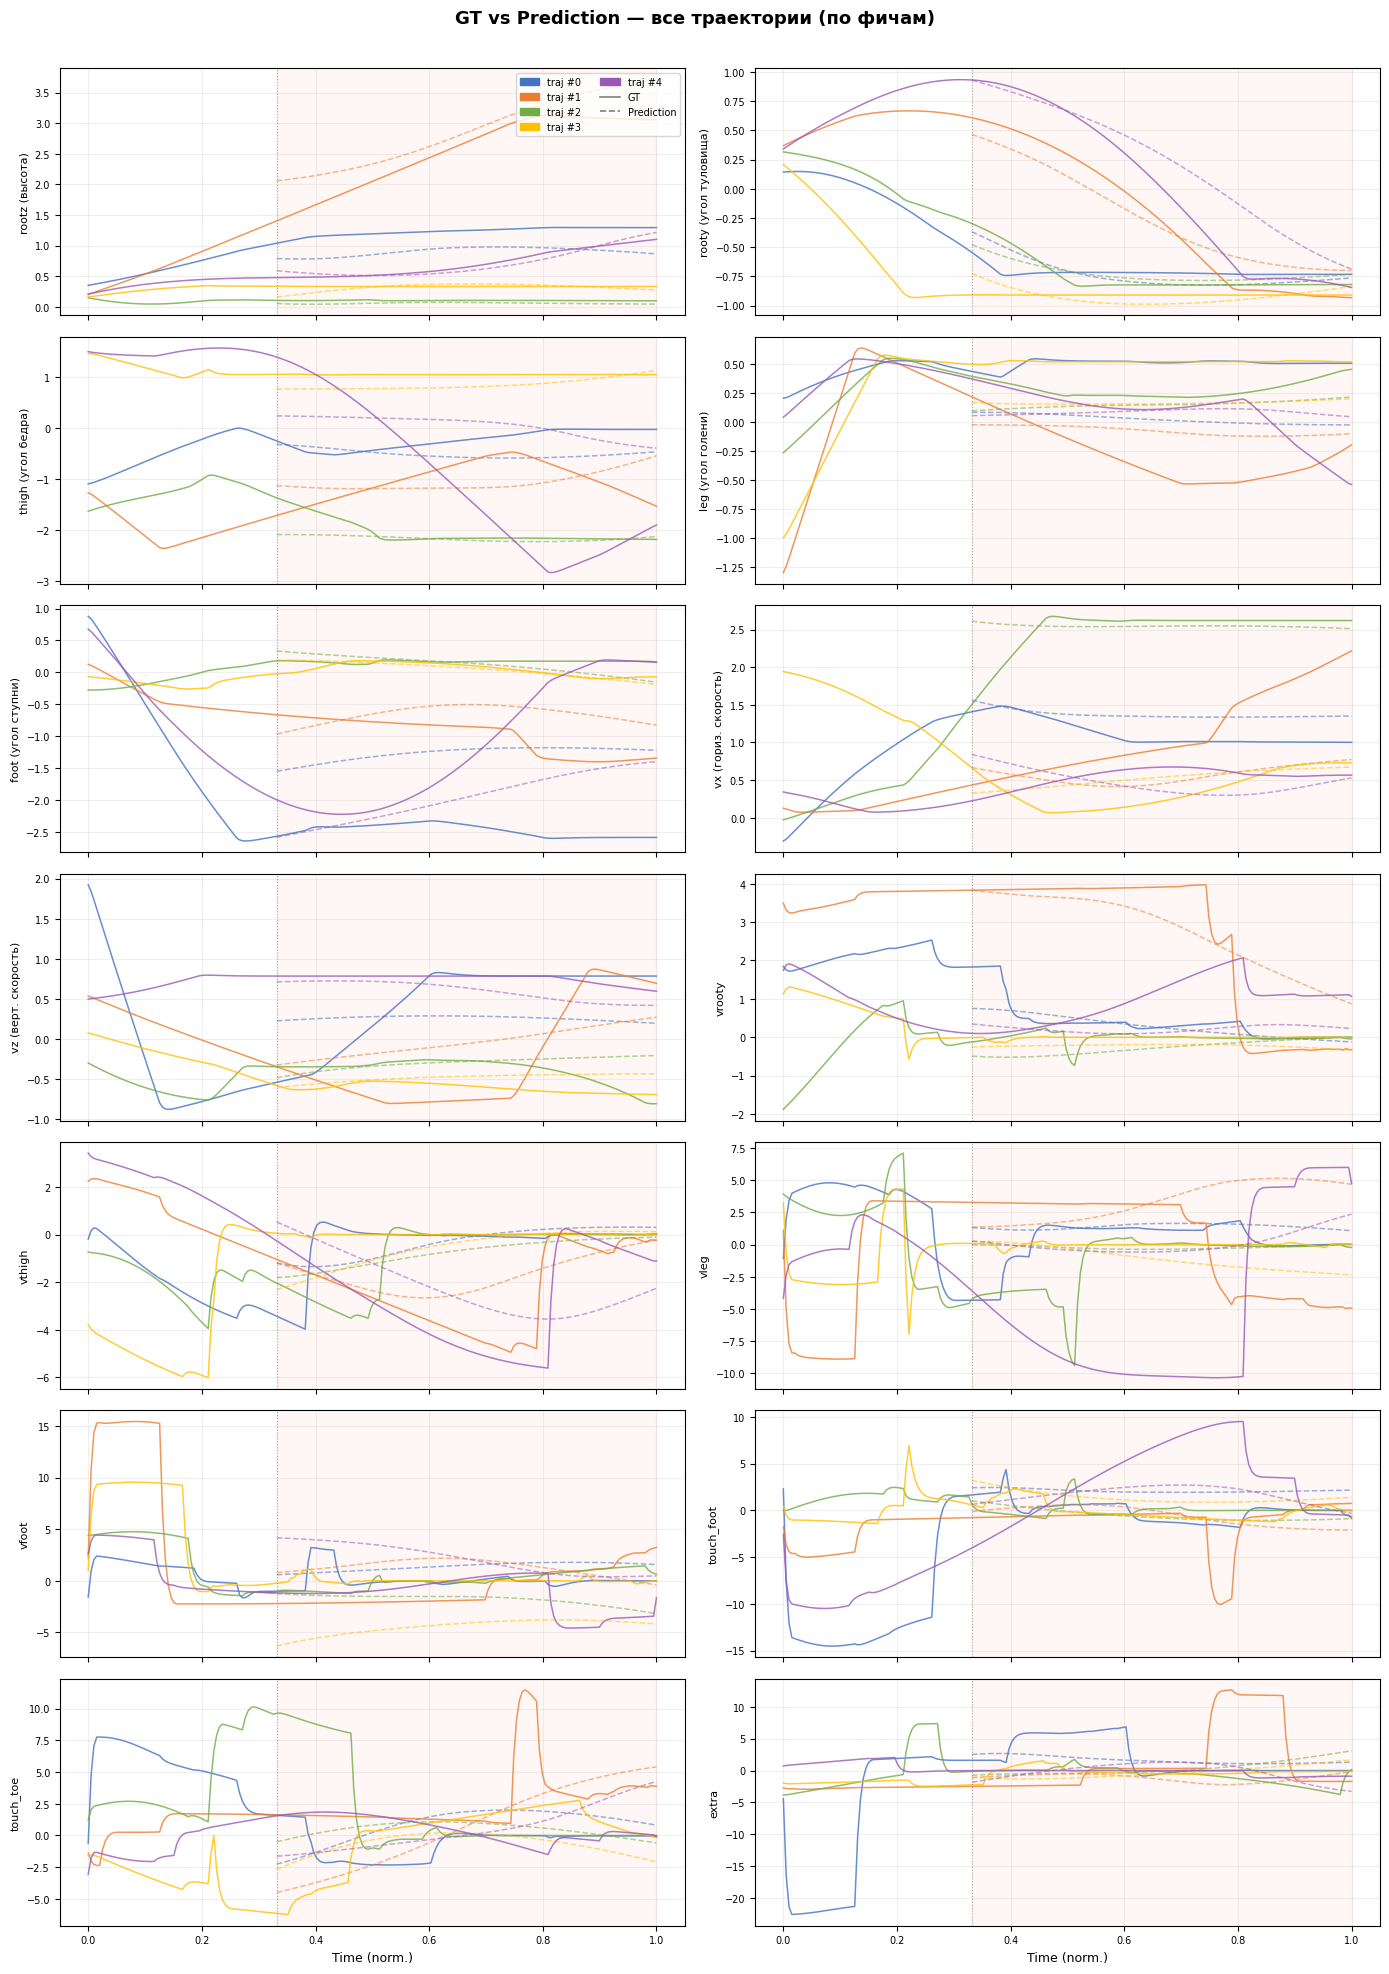

Сохранено: features_all_trajs.png


In [17]:
# ── все фичи, несколько траекторий на каждом subplot (оригинальный масштаб) ─
TRAJ_COLORS = ['#4472C4', '#ED7D31', '#70AD47', '#FFC000', '#9B59B6',
               '#E74C3C', '#1ABC9C', '#F39C12']

cols      = 2
rows      = int(np.ceil(C / cols))
fig, axes = plt.subplots(rows, cols,
                          figsize=(7 * cols, 2.8 * rows),
                          sharex=True)
fig.suptitle('GT vs Prediction — все траектории (по фичам)',
             fontsize=13, fontweight='bold', y=1.005)
axes_flat = np.array(axes).flatten()

for ch in range(C):
    ax = axes_flat[ch]
    for ri, r in enumerate(results):
        clr = TRAJ_COLORS[ri % len(TRAJ_COLORS)]
        spl = r['split_t']
        t_a = np.linspace(0, 1, len(r['gt_raw']))
        t_p = t_a[spl:]

        ax.plot(t_a, r['gt_raw'][:, ch],   color=clr, lw=1.1, alpha=0.8)
        ax.plot(t_p, r['pred_raw'][:, ch], color=clr, lw=1.1, ls='--', alpha=0.55)

    t_split = np.linspace(0, 1, T)[results[0]['split_t']]
    ax.axvline(t_split, color='gray', lw=0.8, ls=':', alpha=0.7)
    ax.axvspan(t_split, 1.0, alpha=0.05, color='tomato')
    ax.set_ylabel(CHANNEL_NAMES[ch], fontsize=8)
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=7)

legend_handles = [
    mpatches.Patch(color=TRAJ_COLORS[i], label=f'traj #{r["idx"]}')
    for i, r in enumerate(results)
] + [
    plt.Line2D([0], [0], color='gray', lw=1.2, ls='-',  label='GT'),
    plt.Line2D([0], [0], color='gray', lw=1.2, ls='--', label='Prediction'),
]
axes_flat[0].legend(handles=legend_handles, fontsize=7, loc='upper right', ncol=2)

for ax in axes_flat[C:]:
    ax.set_visible(False)
for ax in axes_flat[C - cols: C]:
    ax.set_xlabel('Time (norm.)', fontsize=9)

plt.tight_layout()
plt.savefig('features_all_trajs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: features_all_trajs.png')


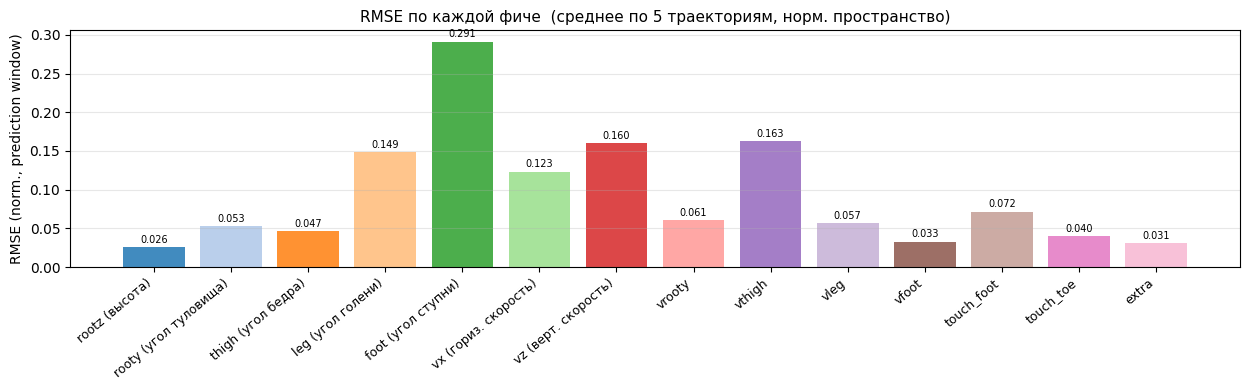

Сохранено: features_rmse.png

Feature                     MSE (norm)  RMSE (norm)
---------------------------------------------------
rootz (высота)                 0.00068      0.02606
rooty (угол туловища)          0.00277      0.05266
thigh (угол бедра)             0.00218      0.04671
leg (угол голени)              0.02216      0.14888
foot (угол ступни)             0.08486      0.29131
vx (гориз. скорость)           0.01520      0.12327
vz (верт. скорость)            0.02557      0.15989
vrooty                         0.00370      0.06083
vthigh                         0.02659      0.16307
vleg                           0.00327      0.05719
vfoot                          0.00108      0.03284
touch_foot                     0.00512      0.07154
touch_toe                      0.00158      0.03976
extra                          0.00098      0.03134


In [18]:
# ── RMSE по каждой фиче (нормализованное пространство) ────────────────────
rmse_per_ch = np.zeros((len(results), C))
for ri, r in enumerate(results):
    spl  = r['split_t']
    diff = r['gt_norm'][spl:] - r['pred_norm']   # (T_pred, C)
    rmse_per_ch[ri] = np.sqrt((diff ** 2).mean(axis=0))

mean_rmse = rmse_per_ch.mean(axis=0)

fig, ax = plt.subplots(figsize=(max(8, C * 0.9), 4))
x    = np.arange(C)
bars = ax.bar(x, mean_rmse, color=[plt.cm.tab20.colors[i % 20] for i in range(C)], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CHANNEL_NAMES[:C], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('RMSE (norm., prediction window)', fontsize=10)
ax.set_title(f'RMSE по каждой фиче  (среднее по {len(results)} траекториям, норм. пространство)',
             fontsize=11)
ax.grid(axis='y', alpha=0.3)

vmax = mean_rmse.max()
for bar, val in zip(bars, mean_rmse):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01 * vmax,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('features_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: features_rmse.png')

print(f'\n{"Feature":<25} {"MSE (norm)":>12} {"RMSE (norm)":>12}')
print('-' * 51)
for name, val in zip(CHANNEL_NAMES[:C], mean_rmse):
    print(f'{name:<25} {val**2:>12.5f} {val:>12.5f}')


In [19]:
# ── MSE внутри одной траектории: по каждой фиче и суммарно ────────────────
WHICH = 0   # индекс в TRAJ_INDICES

r    = results[WHICH]
spl  = r['split_t']
gt   = r['gt_norm'][spl:]      # нормализованные GT (T_pred, C)
pred = r['pred_norm']           # нормализованные предсказания

diff_sq    = (gt - pred) ** 2
mse_per_ch = diff_sq.mean(axis=0)
mse_total  = diff_sq.mean()

print(f'Траектория #{r["idx"]}  |  предсказываемых точек: {len(gt)}  (нормализованное пространство)')
print(f'\n{"Фича":<25} {"MSE":>10} {"RMSE":>10}')
print('-' * 47)
for name, m in zip(CHANNEL_NAMES[:C], mse_per_ch):
    print(f'{name:<25} {m:>10.5f} {m**0.5:>10.5f}')
print('-' * 47)
print(f'{"ИТОГО (все фичи)":<25} {mse_total:>10.5f} {mse_total**0.5:>10.5f}')


Траектория #0  |  предсказываемых точек: 134  (нормализованное пространство)

Фича                             MSE       RMSE
-----------------------------------------------
rootz (высота)               0.00249    0.04985
rooty (угол туловища)        0.00147    0.03833
thigh (угол бедра)           0.00083    0.02887
leg (угол голени)            0.05901    0.24292
foot (угол ступни)           0.37259    0.61040
vx (гориз. скорость)         0.00890    0.09436
vz (верт. скорость)          0.06593    0.25677
vrooty                       0.00131    0.03625
vthigh                       0.01665    0.12905
vleg                         0.00078    0.02801
vfoot                        0.00031    0.01769
touch_foot                   0.00579    0.07608
touch_toe                    0.00093    0.03052
extra                        0.00080    0.02829
-----------------------------------------------
ИТОГО (все фичи)             0.03841    0.19600


In [20]:
# ── Средний MSE на трейне и тесте (нормализованное пространство) ──────────
N_EVAL     = 200
TRAIN_FRAC = 0.8
SEED       = 42

rng       = np.random.default_rng(SEED)
train_end = int(N * TRAIN_FRAC)

train_idx = rng.choice(np.arange(0, train_end),         size=min(N_EVAL, train_end),       replace=False)
test_idx  = rng.choice(np.arange(train_end, N),         size=min(N_EVAL, N - train_end),   replace=False)

def eval_mse(indices, label):
    mse_list = []
    for i, idx in enumerate(indices):
        if (i + 1) % 50 == 0:
            print(f'  [{label}] {i+1}/{len(indices)}')
        pred_norm, spl = predict(data_norm[idx])
        diff_sq = (data_norm[idx][spl:] - pred_norm) ** 2
        mse_list.append(diff_sq.mean())
    arr = np.array(mse_list)
    return arr.mean(), arr.std()

print(f'Train: {train_end} траекторий, оцениваем {len(train_idx)}')
print(f'Test:  {N - train_end} траекторий, оцениваем {len(test_idx)}')

train_mse, train_std = eval_mse(train_idx, 'TRAIN')
test_mse,  test_std  = eval_mse(test_idx,  'TEST')

print(f'\n(нормализованное пространство)')
print(f'{"":10} {"MSE":>10} {"±std":>10} {"RMSE":>10}')
print('-' * 42)
print(f'{"Train":<10} {train_mse:>10.5f} {train_std:>10.5f} {train_mse**0.5:>10.5f}')
print(f'{"Test":<10} {test_mse:>10.5f} {test_std:>10.5f} {test_mse**0.5:>10.5f}')


Train: 8000 траекторий, оцениваем 200
Test:  2000 траекторий, оцениваем 200


c:\Users\ilyak\miniconda3\envs\torch_env\Lib\site-packages\torchdiffeq\_impl\misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


  [TRAIN] 50/200
  [TRAIN] 100/200
  [TRAIN] 150/200
  [TRAIN] 200/200
  [TEST] 50/200
  [TEST] 100/200
  [TEST] 150/200
  [TEST] 200/200

(нормализованное пространство)
                  MSE       ±std       RMSE
------------------------------------------
Train         0.01457    0.00884    0.12070
Test          0.01474    0.00854    0.12142
